In [188]:
import pandas as pb
import numpy as np

from sklearn.ensemble import StackingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Combination of over and under sampling
from imblearn.combine import SMOTETomek
from imblearn.combine import SMOTEENN

from datasets import load_dataset
from huggingface_hub import hf_hub_download

import utils

In [189]:
onehot_events_df = utils.read_and_onehot_events("../data-processing/events.csv")

In [190]:
# Load dataset splits
train_dataset = load_dataset("sookiemonster/asrs-narratives", split="train")
validation_dataset = load_dataset("sookiemonster/asrs-narratives", split="validation")
test_dataset = load_dataset("sookiemonster/asrs-narratives", split="test")

train_acns = set(train_dataset["acn"])
validation_acns = set(validation_dataset["acn"])
test_acns = set(test_dataset["acn"])

print(len(train_acns))
print(len(validation_acns))
print(len(test_acns))

10360
4441
9868


In [191]:
# Split up the main dataframe
train_events_df = onehot_events_df.iloc[onehot_events_df.index.isin(train_acns)]
validation_events_df = onehot_events_df.iloc[onehot_events_df.index.isin(validation_acns)]
test_events_df = onehot_events_df.iloc[onehot_events_df.index.isin(test_acns)]

print(len(train_events_df))
print(len(validation_events_df))
print(len(test_events_df))

10293
4415
9826


In [192]:
trainX = train_events_df.drop(columns="assessments_primary_problem")
trainY = train_events_df["assessments_primary_problem"]

testX = test_events_df.drop(columns="assessments_primary_problem")
testY = test_events_df["assessments_primary_problem"]

Stacking Classifiers

In [193]:
onehot_events_df.assessments_primary_problem.value_counts()

assessments_primary_problem
human_factors                                   8384
aircraft                                        8207
procedure                                       2403
ambiguous                                       1985
weather                                          821
airport                                          609
environment___non_weather_related                595
chart_or_publication                             335
airspace_structure                               321
atc_equipment_/_nav_facility_/_buildings         316
software_and_automation                          168
company_policy                                   132
equipment_/_tooling                               96
mel                                               57
incorrect_/_not_installed_/_unavailable_part      48
staffing                                          27
manuals                                           25
logbook_entry                                      5
Name: count, dtype

In [194]:
high_confidence_problems = ["human_factors", "aircraft", "weather"]

medium_confidence_problems = ["airport", "ambiguous", "atc_equipment_/_nav_facility_/_buildings", "chart_or_publication"]

low_confidence_problems = ["airspace_structure", "company_policy", "environment___non_weather_related",
                           "equipment_/_tooling", "incorrect_/_not_installed_/_unavailable_part", "logbook_entry", 
                           "manuals", "mel", "procedure", "software_and_automation", "staffing"]

In [195]:
high_confidence_train_df = train_events_df[train_events_df["assessments_primary_problem"].isin(high_confidence_problems)]
medium_confidence_train_df = train_events_df[train_events_df["assessments_primary_problem"].isin(medium_confidence_problems)]
low_confidence_train_df = train_events_df[train_events_df["assessments_primary_problem"].isin(low_confidence_problems)]

high_confidence_test_df = test_events_df[test_events_df["assessments_primary_problem"].isin(high_confidence_problems)]
medium_confidence_test_df = test_events_df[test_events_df["assessments_primary_problem"].isin(medium_confidence_problems)]
low_confidence_test_df = test_events_df[test_events_df["assessments_primary_problem"].isin(low_confidence_problems)]

In [196]:
hc_ovr = OneVsRestClassifier(SVC(), n_jobs=-1)
mc_ovr = OneVsRestClassifier(SVC(), n_jobs=-1)
lc_ovr = OneVsRestClassifier(SVC(), n_jobs=-1)

High-Confidence Classifier

In [197]:
hc_trainX = high_confidence_train_df.drop(columns="assessments_primary_problem")
hc_trainY = high_confidence_train_df["assessments_primary_problem"]

hc_testX = high_confidence_test_df.drop(columns="assessments_primary_problem")
hc_testY = high_confidence_test_df["assessments_primary_problem"]

In [198]:
hc_ovr.fit(hc_trainX, hc_trainY)

,estimator,SVC()
,n_jobs,-1
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


               precision    recall  f1-score   support

     aircraft       0.91      0.97      0.94      3286
human_factors       0.94      0.90      0.92      3359
      weather       0.80      0.61      0.69       328

     accuracy                           0.92      6973
    macro avg       0.88      0.83      0.85      6973
 weighted avg       0.92      0.92      0.92      6973



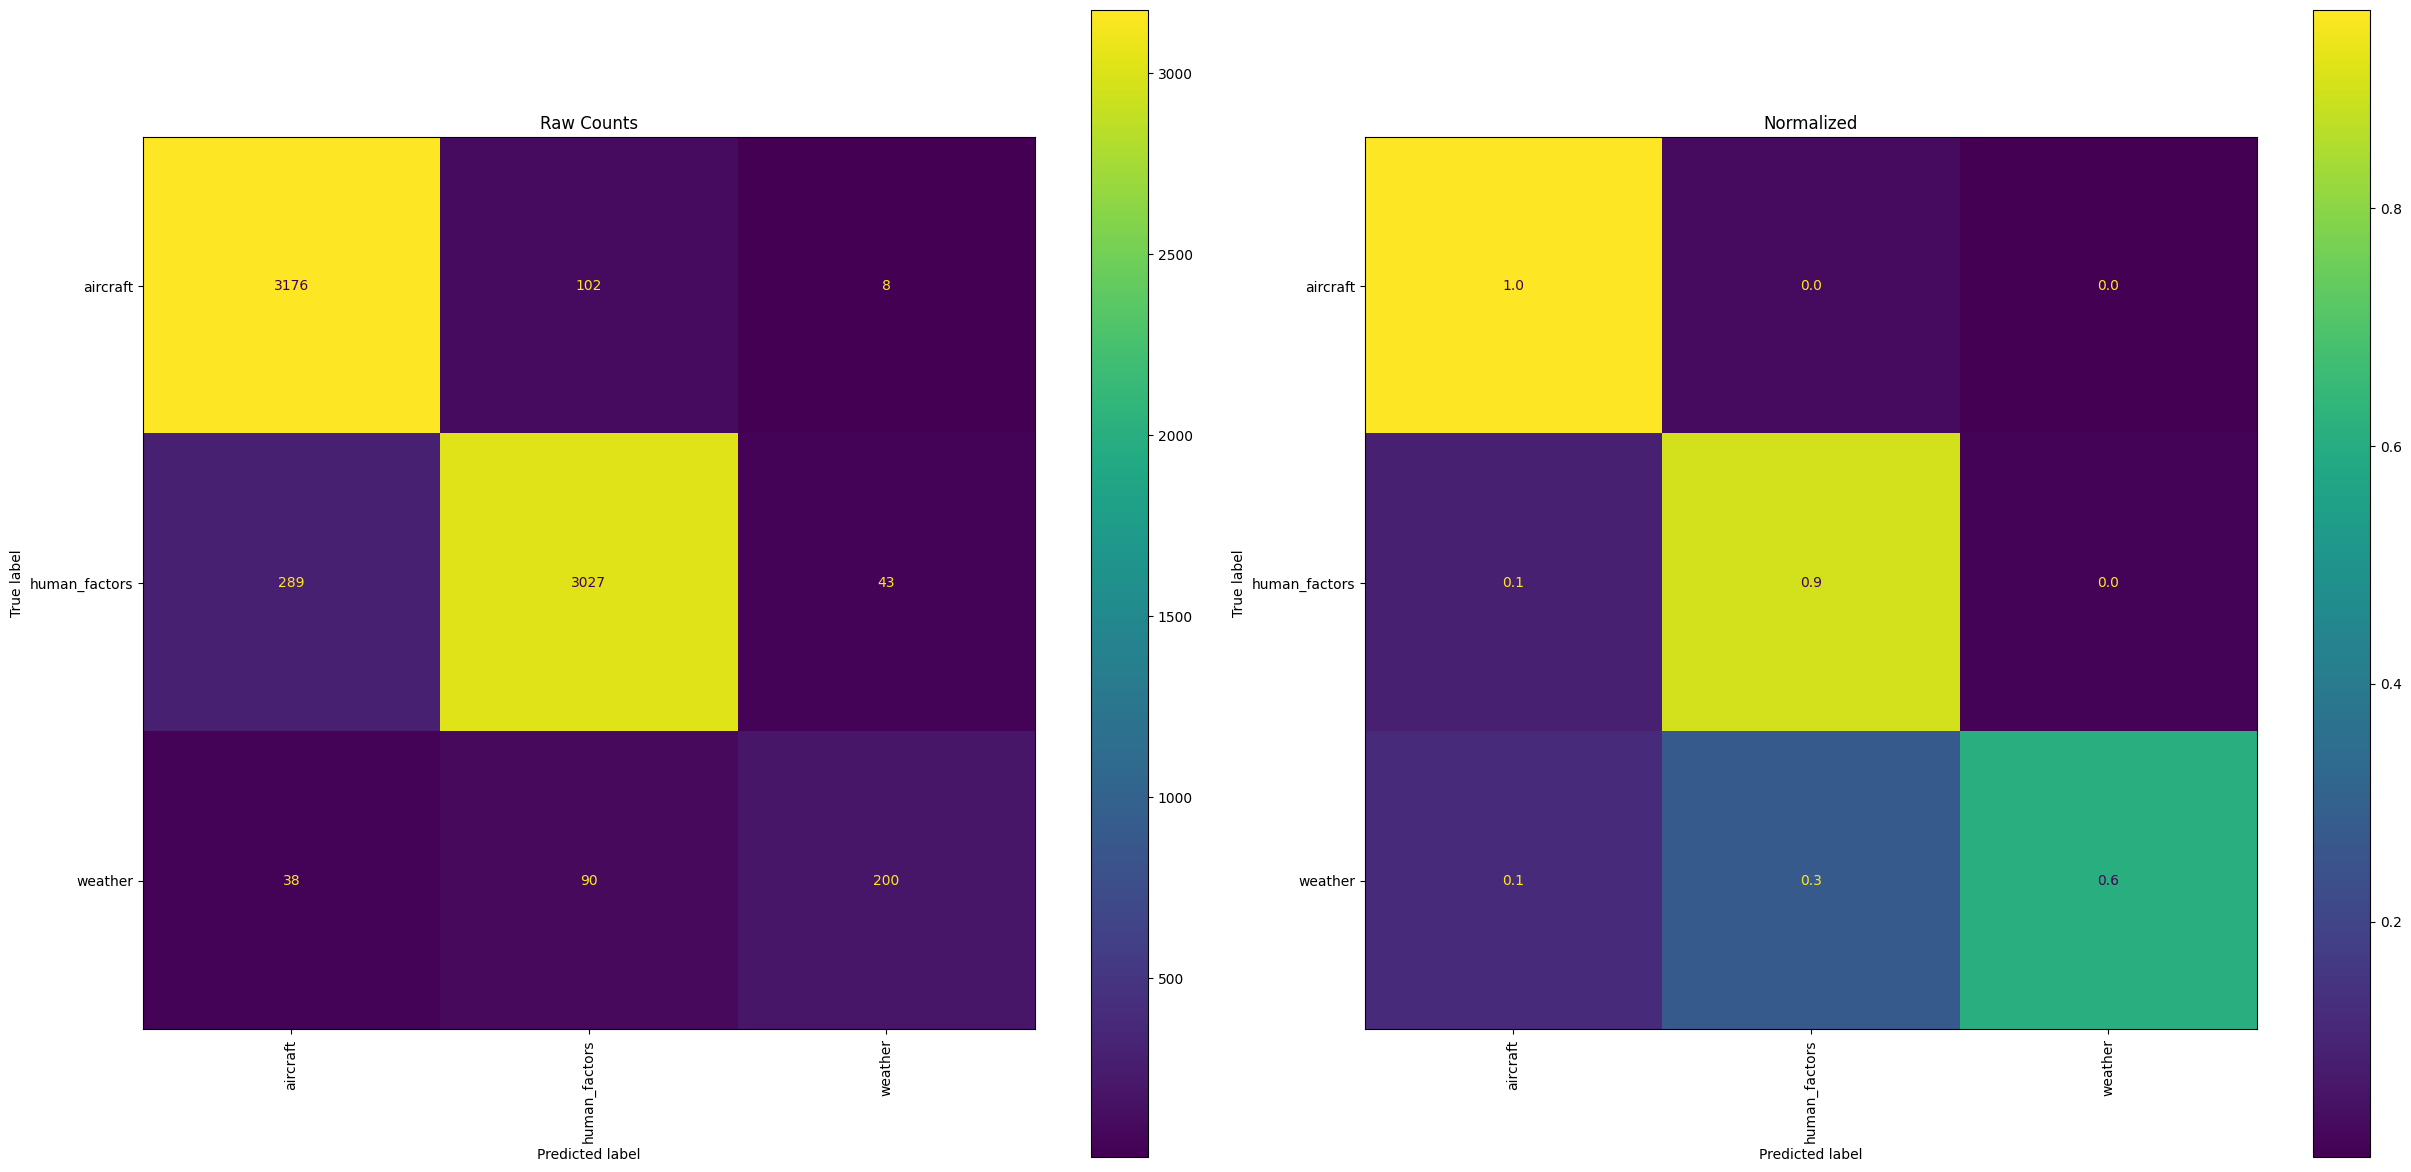

In [199]:
hc_predY = hc_ovr.predict(hc_testX)
utils.visualize_eval(hc_testY, hc_predY, "High Confidence")

Medium-Confidence Classifier

In [200]:
mc_trainX = medium_confidence_train_df.drop(columns="assessments_primary_problem")
mc_trainY = medium_confidence_train_df["assessments_primary_problem"]

mc_testX = medium_confidence_test_df.drop(columns="assessments_primary_problem")
mc_testY = medium_confidence_test_df["assessments_primary_problem"]

In [201]:
mc_ovr.fit(mc_trainX, mc_trainY)

,estimator,SVC()
,n_jobs,-1
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


                                          precision    recall  f1-score   support

                                 airport       0.61      0.58      0.60       244
                               ambiguous       0.81      0.92      0.86       795
atc_equipment_/_nav_facility_/_buildings       0.75      0.40      0.52       126
                    chart_or_publication       0.65      0.45      0.53       134

                                accuracy                           0.76      1299
                               macro avg       0.70      0.59      0.63      1299
                            weighted avg       0.75      0.76      0.74      1299



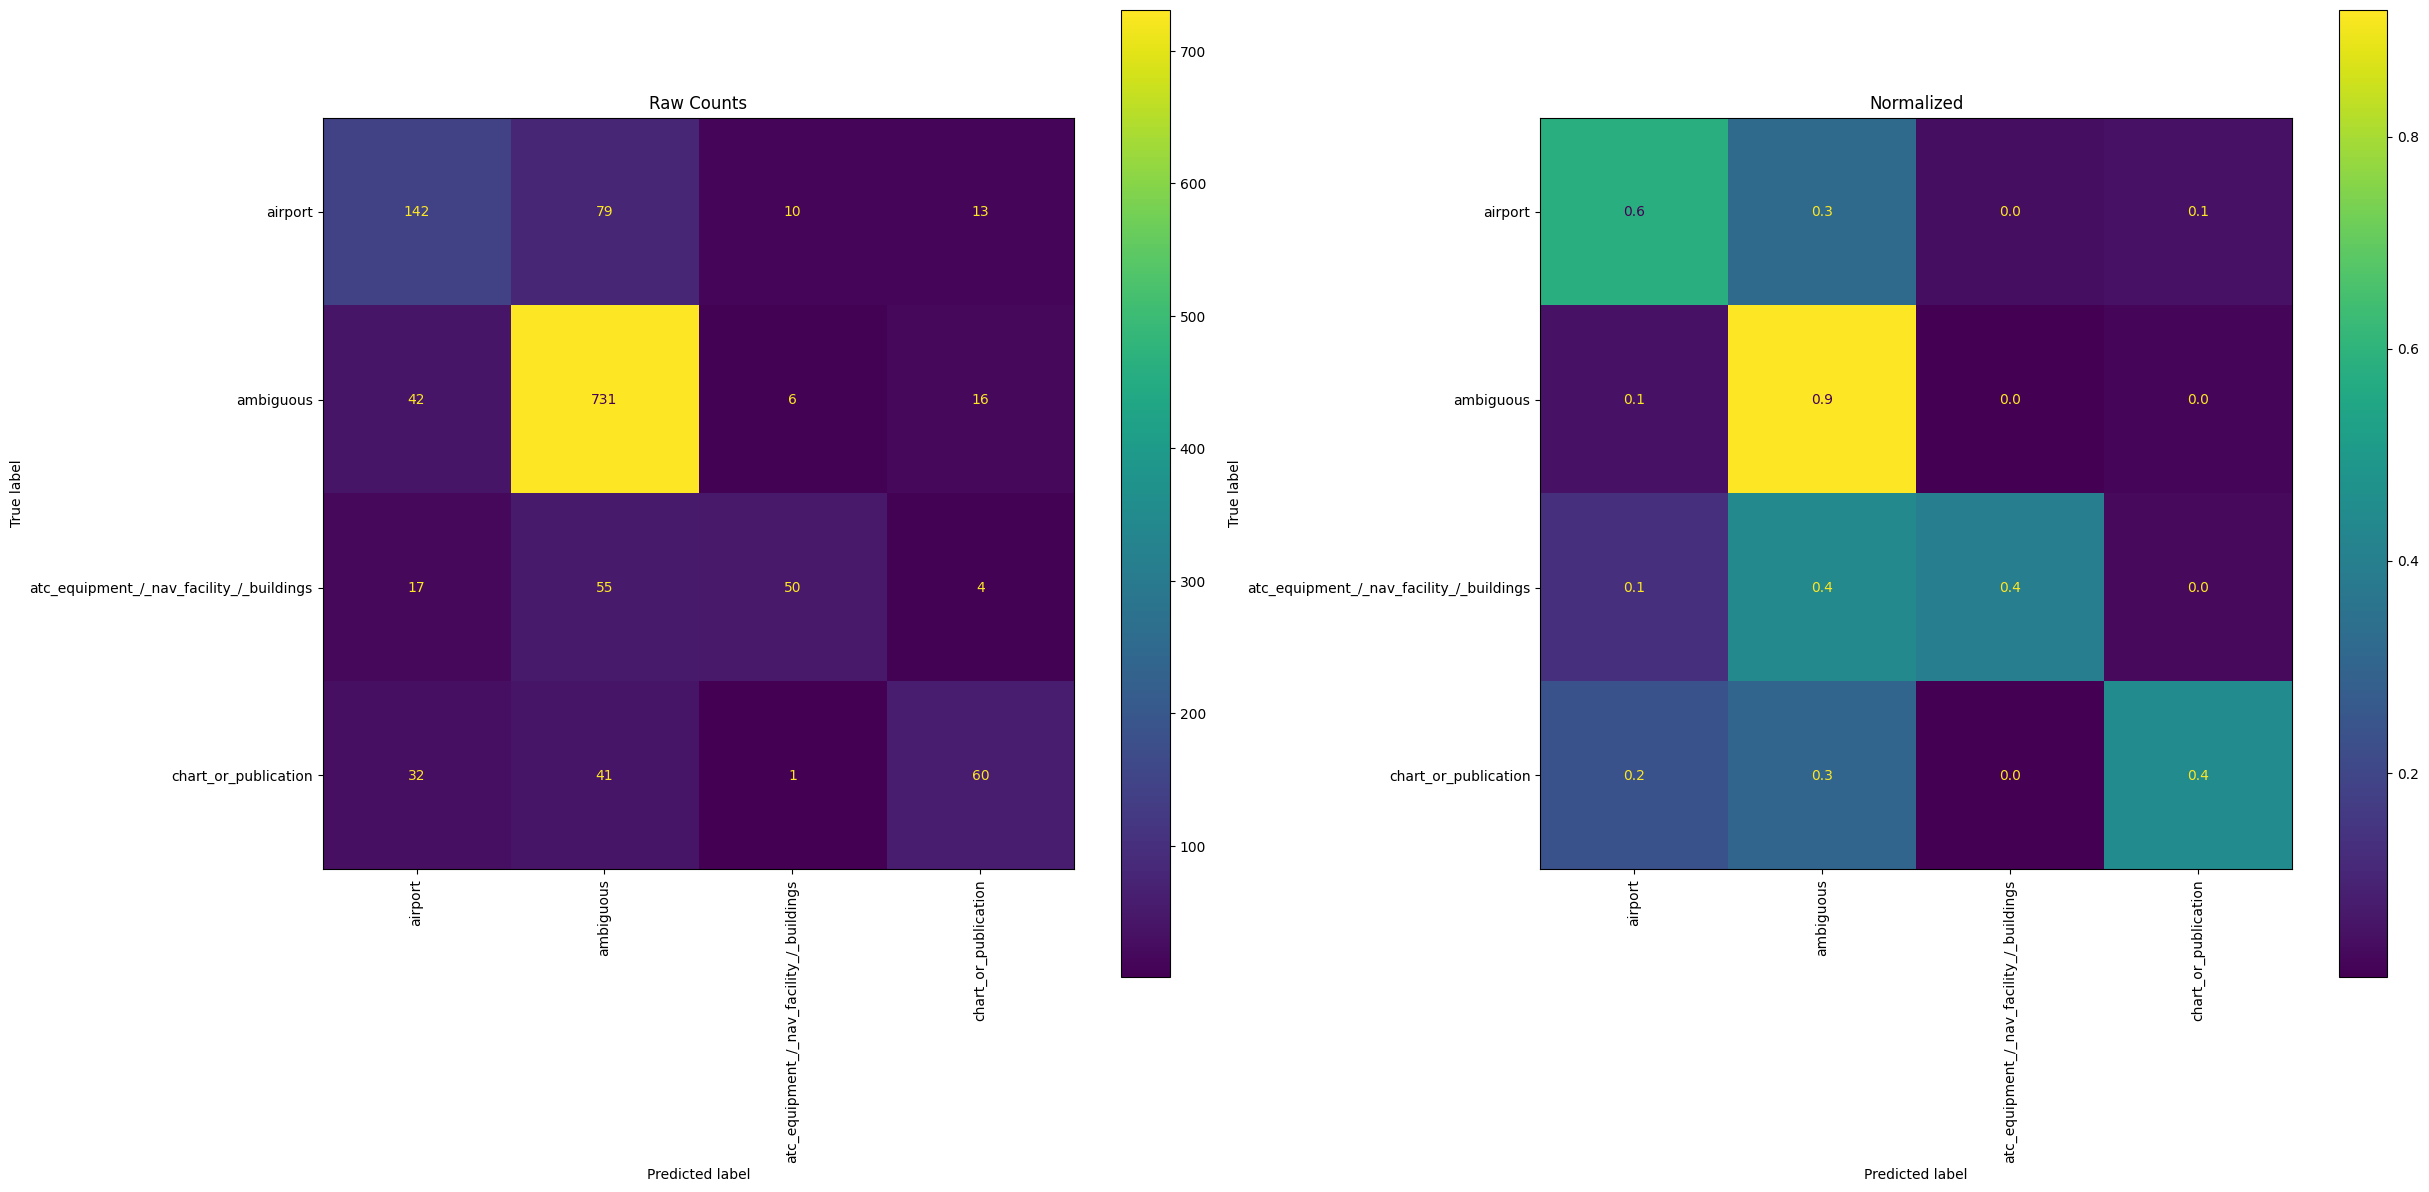

In [202]:
mc_predY = mc_ovr.predict(mc_testX)
utils.visualize_eval(mc_testY, mc_predY, "Medium Confidence")

Low-Confidence Classifier

In [203]:
lc_trainX = low_confidence_train_df.drop(columns="assessments_primary_problem")
lc_trainY = low_confidence_train_df["assessments_primary_problem"]

lc_testX = low_confidence_test_df.drop(columns="assessments_primary_problem")
lc_testY = low_confidence_test_df["assessments_primary_problem"]

In [204]:
lc_ovr.fit(lc_trainX, lc_trainY)

,estimator,SVC()
,n_jobs,-1
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


/home/maciej/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maciej/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maciej/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                                              precision    recall  f1-score   support

                          airspace_structure       0.49      0.14      0.22       129
                              company_policy       0.00      0.00      0.00        53
           environment___non_weather_related       0.65      0.42      0.51       238
                         equipment_/_tooling       0.73      0.29      0.42        38
incorrect_/_not_installed_/_unavailable_part       0.00      0.00      0.00        19
                               logbook_entry       0.00      0.00      0.00         2
                                     manuals       0.00      0.00      0.00        10
                                         mel       0.00      0.00      0.00        24
                                   procedure       0.70      0.95      0.81       962
                     software_and_automation       0.39      0.13      0.20        68
                                    staffing       0.

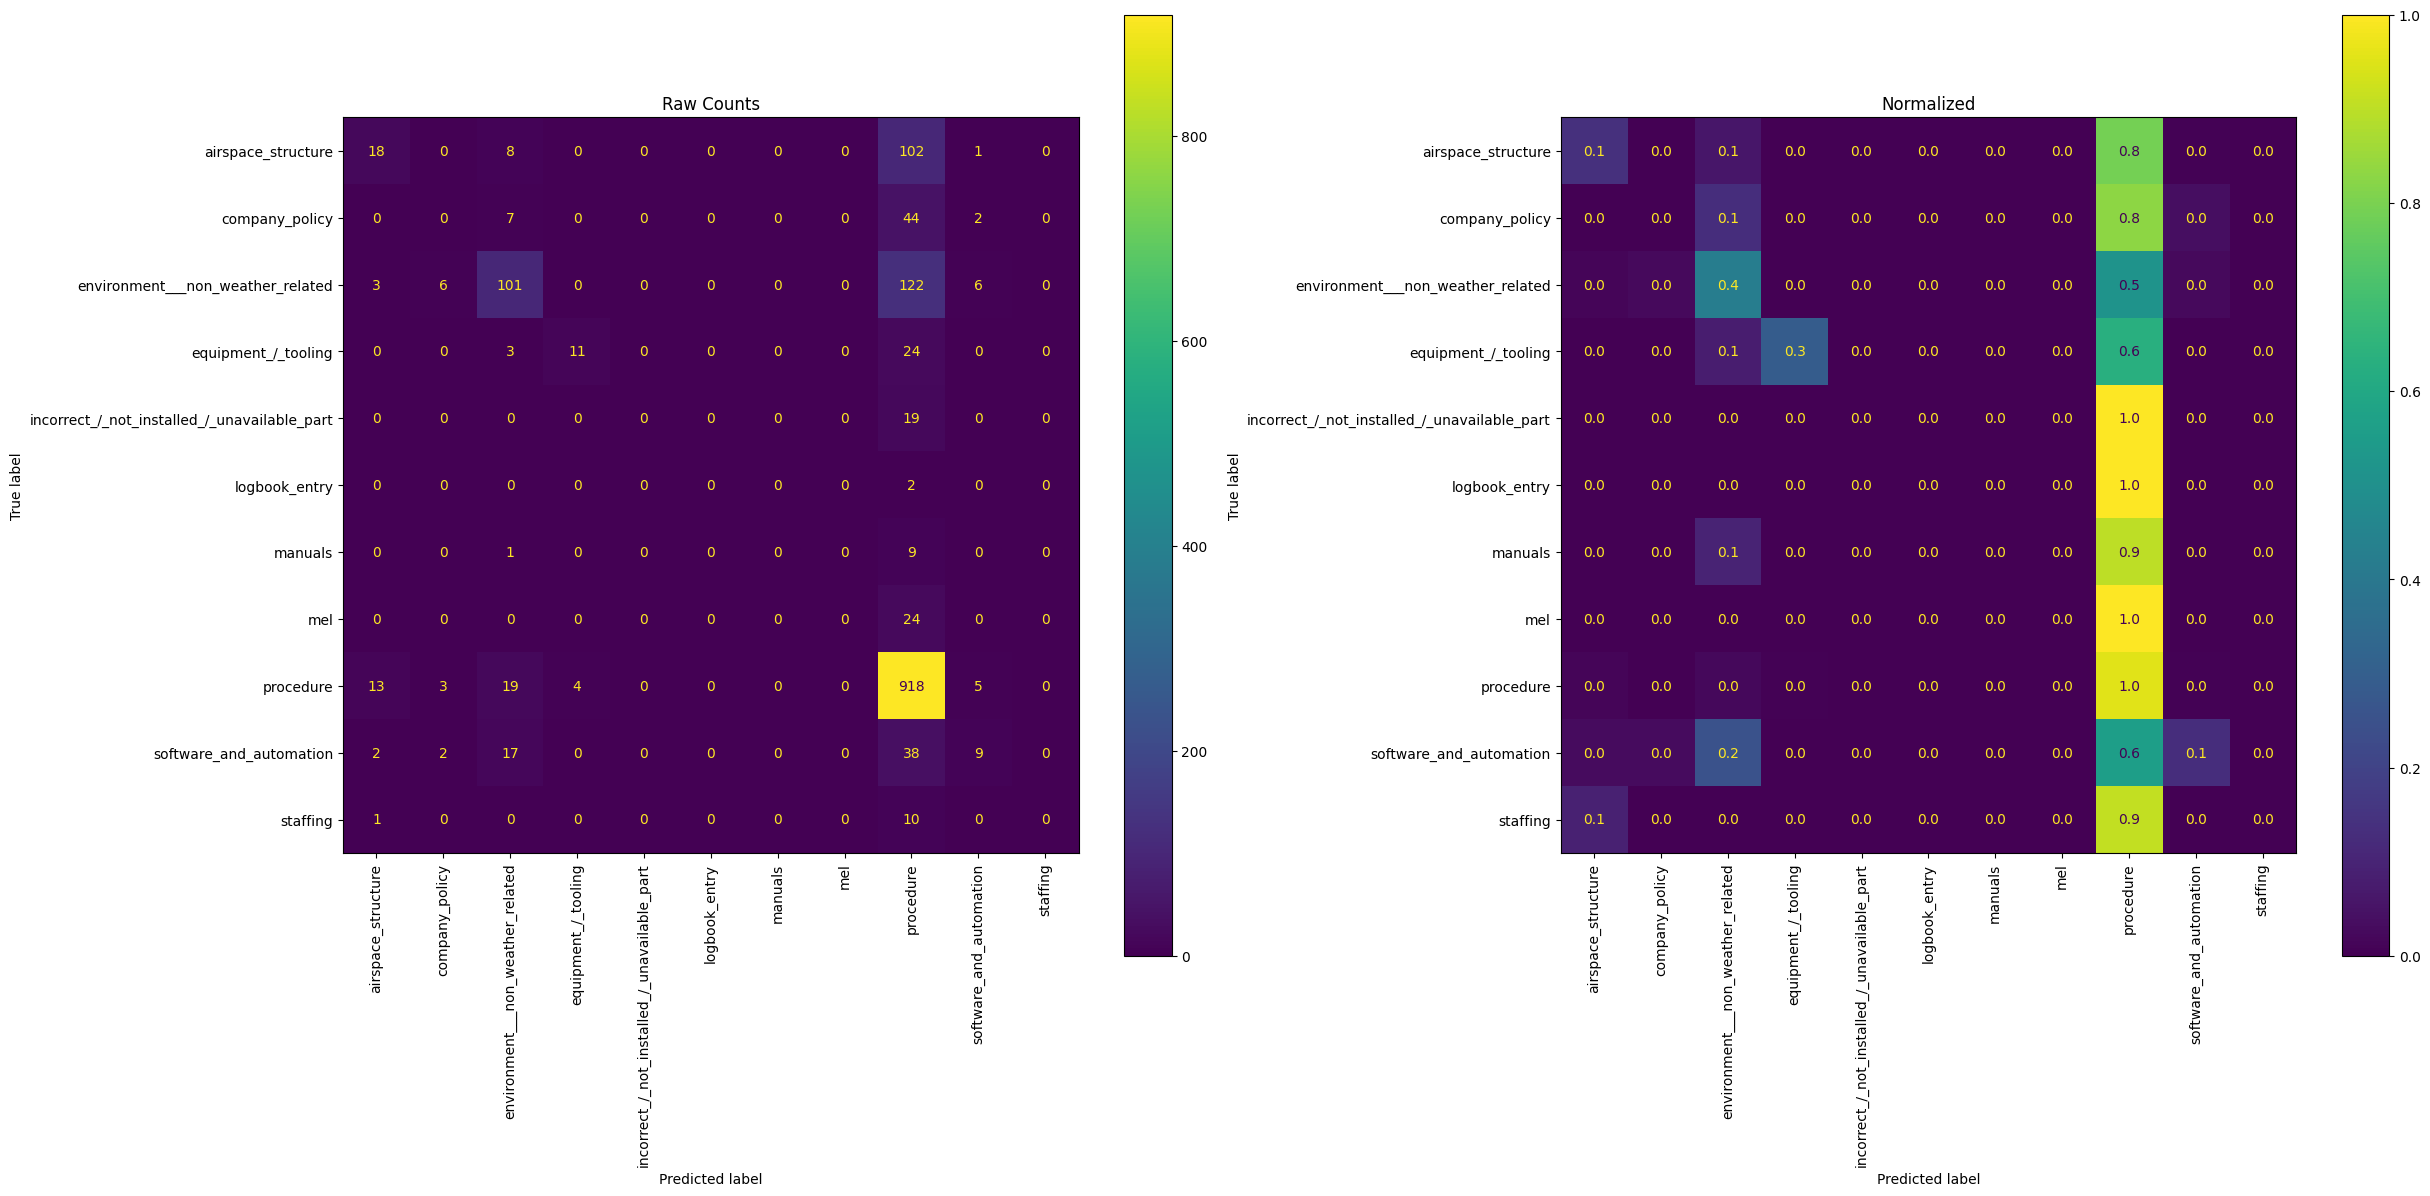

In [205]:
lc_predY = lc_ovr.predict(lc_testX)
utils.visualize_eval(lc_testY, lc_predY, "Low Confidence")

### Separating the data based on sample size

In [206]:
problem_value_counts = onehot_events_df["assessments_primary_problem"].value_counts()

# Threshold the values for each sample
high_sample_problems = problem_value_counts[problem_value_counts >= 500].index  # Index to get the actual problem from value count
medium_sample_problems = problem_value_counts[(problem_value_counts >= 50) & (problem_value_counts < 500)].index
low_sample_problems = problem_value_counts[problem_value_counts < 100].index

In [207]:
high_sample_train_df = train_events_df[train_events_df["assessments_primary_problem"].isin(high_sample_problems)]
medium_sample_train_df = train_events_df[train_events_df["assessments_primary_problem"].isin(medium_sample_problems)]
low_sample_train_df = train_events_df[train_events_df["assessments_primary_problem"].isin(low_sample_problems)]


high_sample_test_df = test_events_df[test_events_df["assessments_primary_problem"].isin(high_sample_problems)]
medium_sample_test_df = test_events_df[test_events_df["assessments_primary_problem"].isin(medium_sample_problems)]
low_sample_test_df = test_events_df[test_events_df["assessments_primary_problem"].isin(low_sample_problems)]

In [208]:
# Needs some extra help classifying human-factors and procedures problems
hf_proc_train_df = high_sample_train_df[(high_sample_train_df["assessments_primary_problem"] == "human_factors") | 
                                        (high_sample_train_df["assessments_primary_problem"] == "aircraft") |
                                        (high_sample_train_df["assessments_primary_problem"] == "procedure")]

hf_proc_test_df = high_sample_test_df[(high_sample_test_df["assessments_primary_problem"] == "human_factors") | 
                                      (high_sample_test_df["assessments_primary_problem"] == "aircraft") |
                                      (high_sample_test_df["assessments_primary_problem"] == "procedure")]



high_sample_train_df = high_sample_train_df[(high_sample_train_df["assessments_primary_problem"] != "human_factors") & 
                                            (high_sample_train_df["assessments_primary_problem"] != "aircraft") &
                                            (high_sample_train_df["assessments_primary_problem"] != "procedure")]

high_sample_test_df = high_sample_test_df[(high_sample_test_df["assessments_primary_problem"] != "human_factors") &
                                          (high_sample_test_df["assessments_primary_problem"] != "aircraft") &
                                          (high_sample_test_df["assessments_primary_problem"] != "procedure")]

In [209]:
#from sklearn.neighbors import KNeighborsClassifier
#from sklearn.ensemble import GradientBoostingClassifier

# Tried RandomForest, KNearestNeighbors, GradientBoosting (XGBoost), LogisticRegression
# Testing shows that OneVRest outperformed each for each subset of the data, but I didn't modify any of 
# other classifiers' parameters

hs_ovr = OneVsRestClassifier(SVC())#class_weight="balanced"))
ms_ovr = OneVsRestClassifier(SVC())#class_weight="balanced"))
ls_ovr = OneVsRestClassifier(SVC())#class_weight="balanced"))
hfp_ovr = OneVsRestClassifier(SVC())#class_weight="balanced"))

High-Sample Classification

In [210]:
hs_trainX = high_sample_train_df.drop(columns="assessments_primary_problem")
hs_trainY = high_sample_train_df["assessments_primary_problem"]

hs_testX = high_sample_test_df.drop(columns="assessments_primary_problem")
hs_testY = high_sample_test_df["assessments_primary_problem"]

In [211]:
hs_ovr.fit(hs_trainX, hs_trainY)

,estimator,SVC()
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


                                   precision    recall  f1-score   support

                          airport       0.67      0.65      0.66       244
                        ambiguous       0.72      0.85      0.78       795
environment___non_weather_related       0.79      0.21      0.33       238
                          weather       0.79      0.88      0.83       328

                         accuracy                           0.73      1605
                        macro avg       0.74      0.65      0.65      1605
                     weighted avg       0.74      0.73      0.71      1605



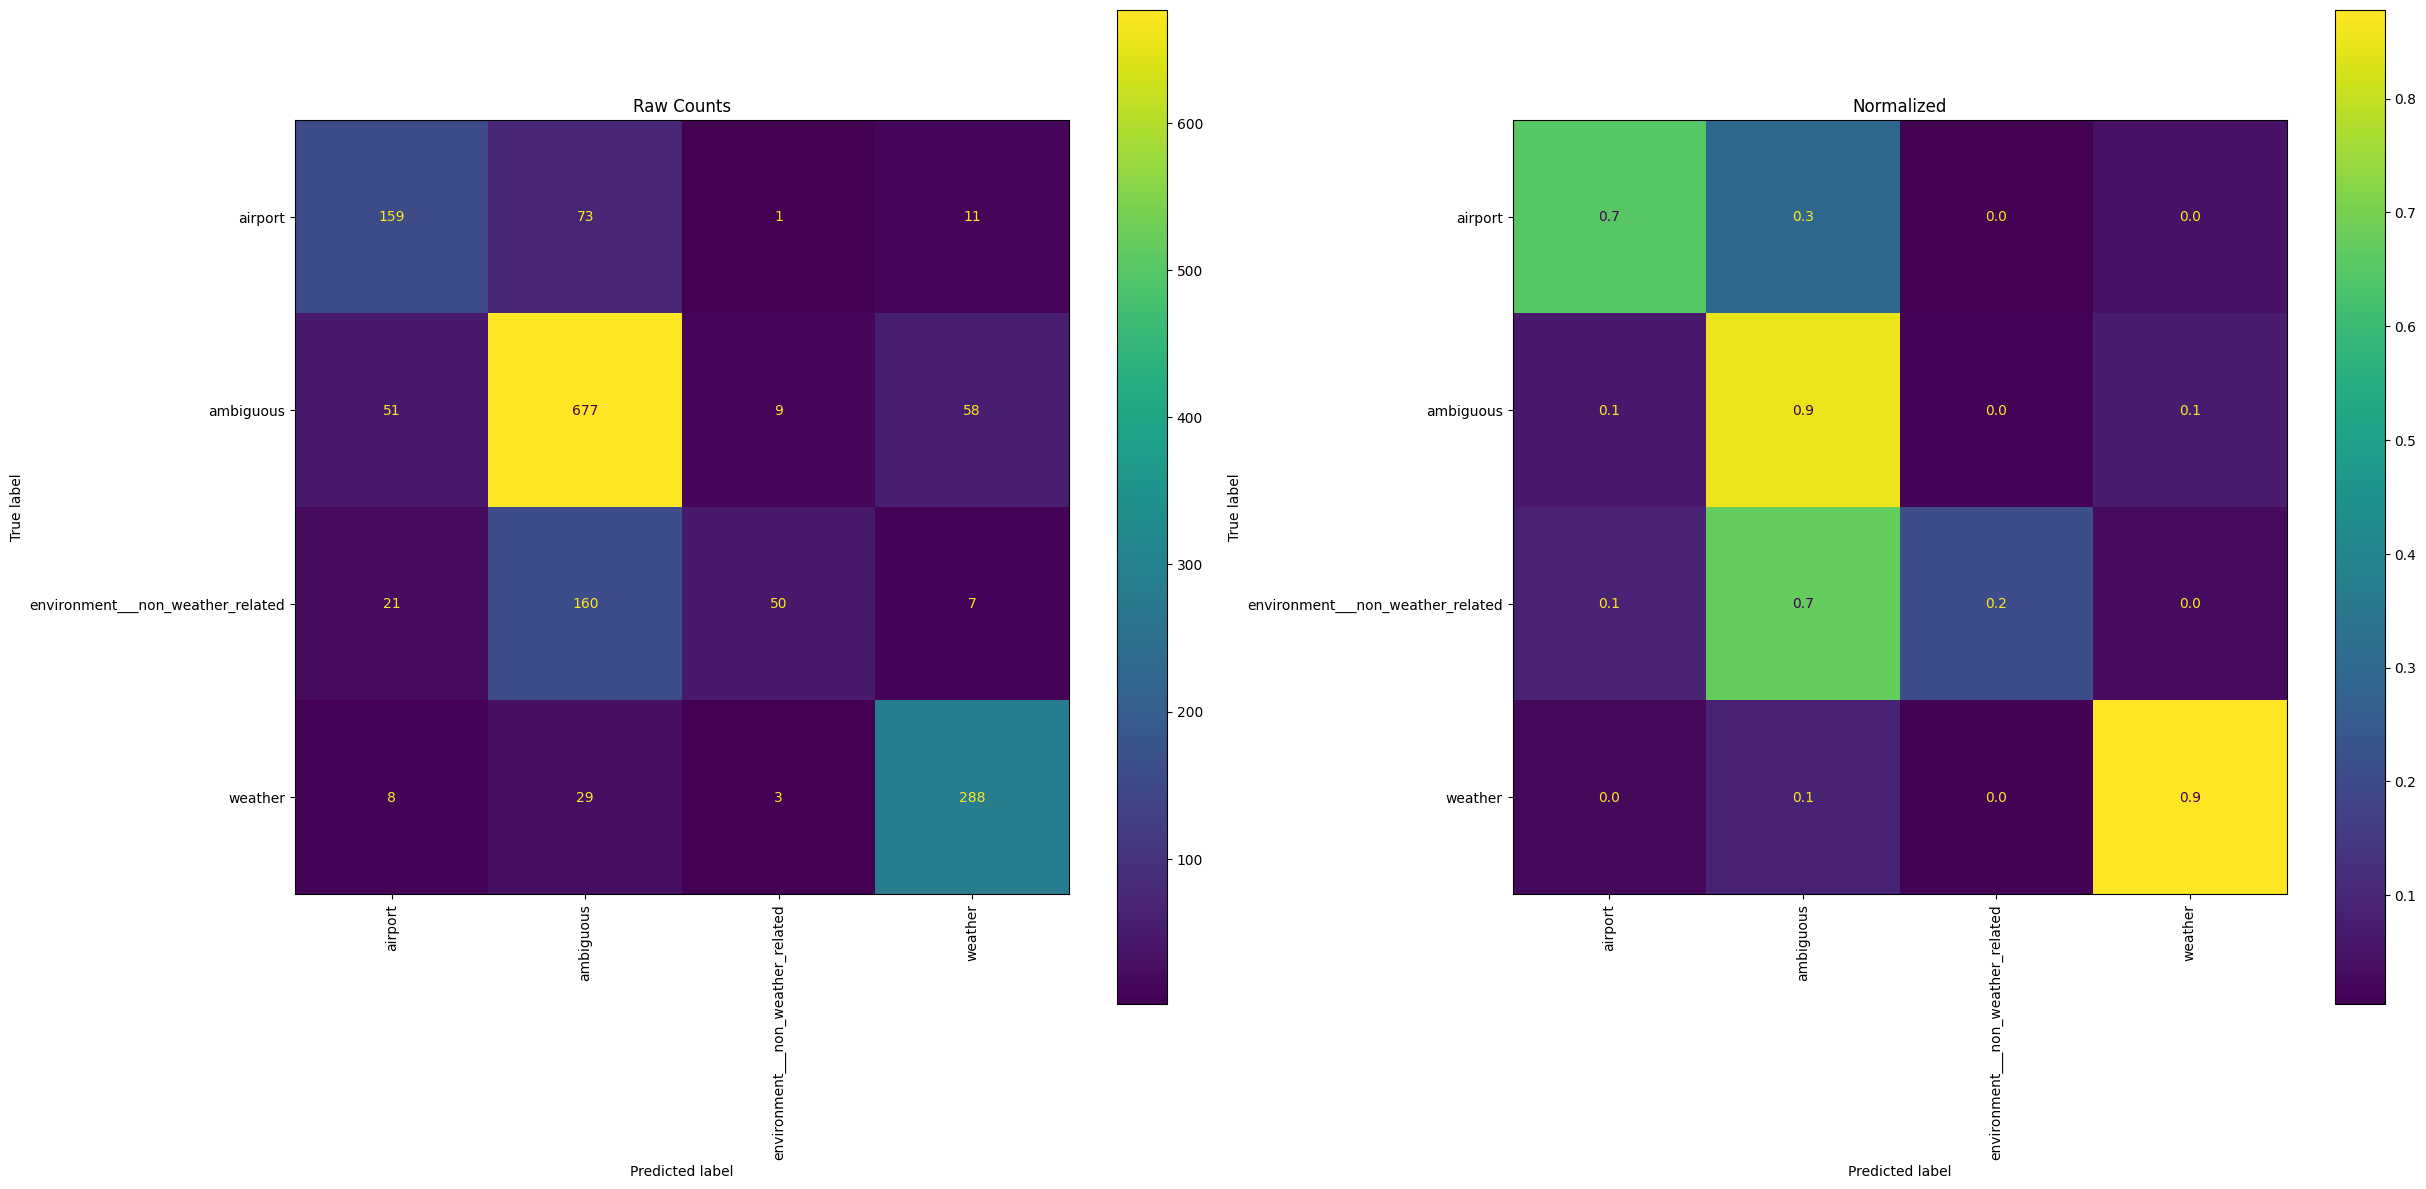

In [212]:
hs_predY = hs_ovr.predict(hs_testX)
utils.visualize_eval(hs_testY, hs_predY, "High Sample")

Medium-Sample Classification

In [213]:
ms_trainX = medium_sample_train_df.drop(columns="assessments_primary_problem")
ms_trainY = medium_sample_train_df["assessments_primary_problem"]

ms_testX = medium_sample_test_df.drop(columns="assessments_primary_problem")
ms_testY = medium_sample_test_df["assessments_primary_problem"]

In [214]:
ms_ovr.fit(ms_trainX, ms_trainY)

,estimator,SVC()
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


                                          precision    recall  f1-score   support

                      airspace_structure       0.77      0.82      0.80       129
atc_equipment_/_nav_facility_/_buildings       0.68      0.77      0.72       126
                    chart_or_publication       0.69      0.83      0.76       134
                          company_policy       0.77      0.32      0.45        53
                     equipment_/_tooling       0.87      0.71      0.78        38
                                     mel       0.67      1.00      0.80        24
                 software_and_automation       0.57      0.37      0.45        68

                                accuracy                           0.71       572
                               macro avg       0.72      0.69      0.68       572
                            weighted avg       0.71      0.71      0.70       572



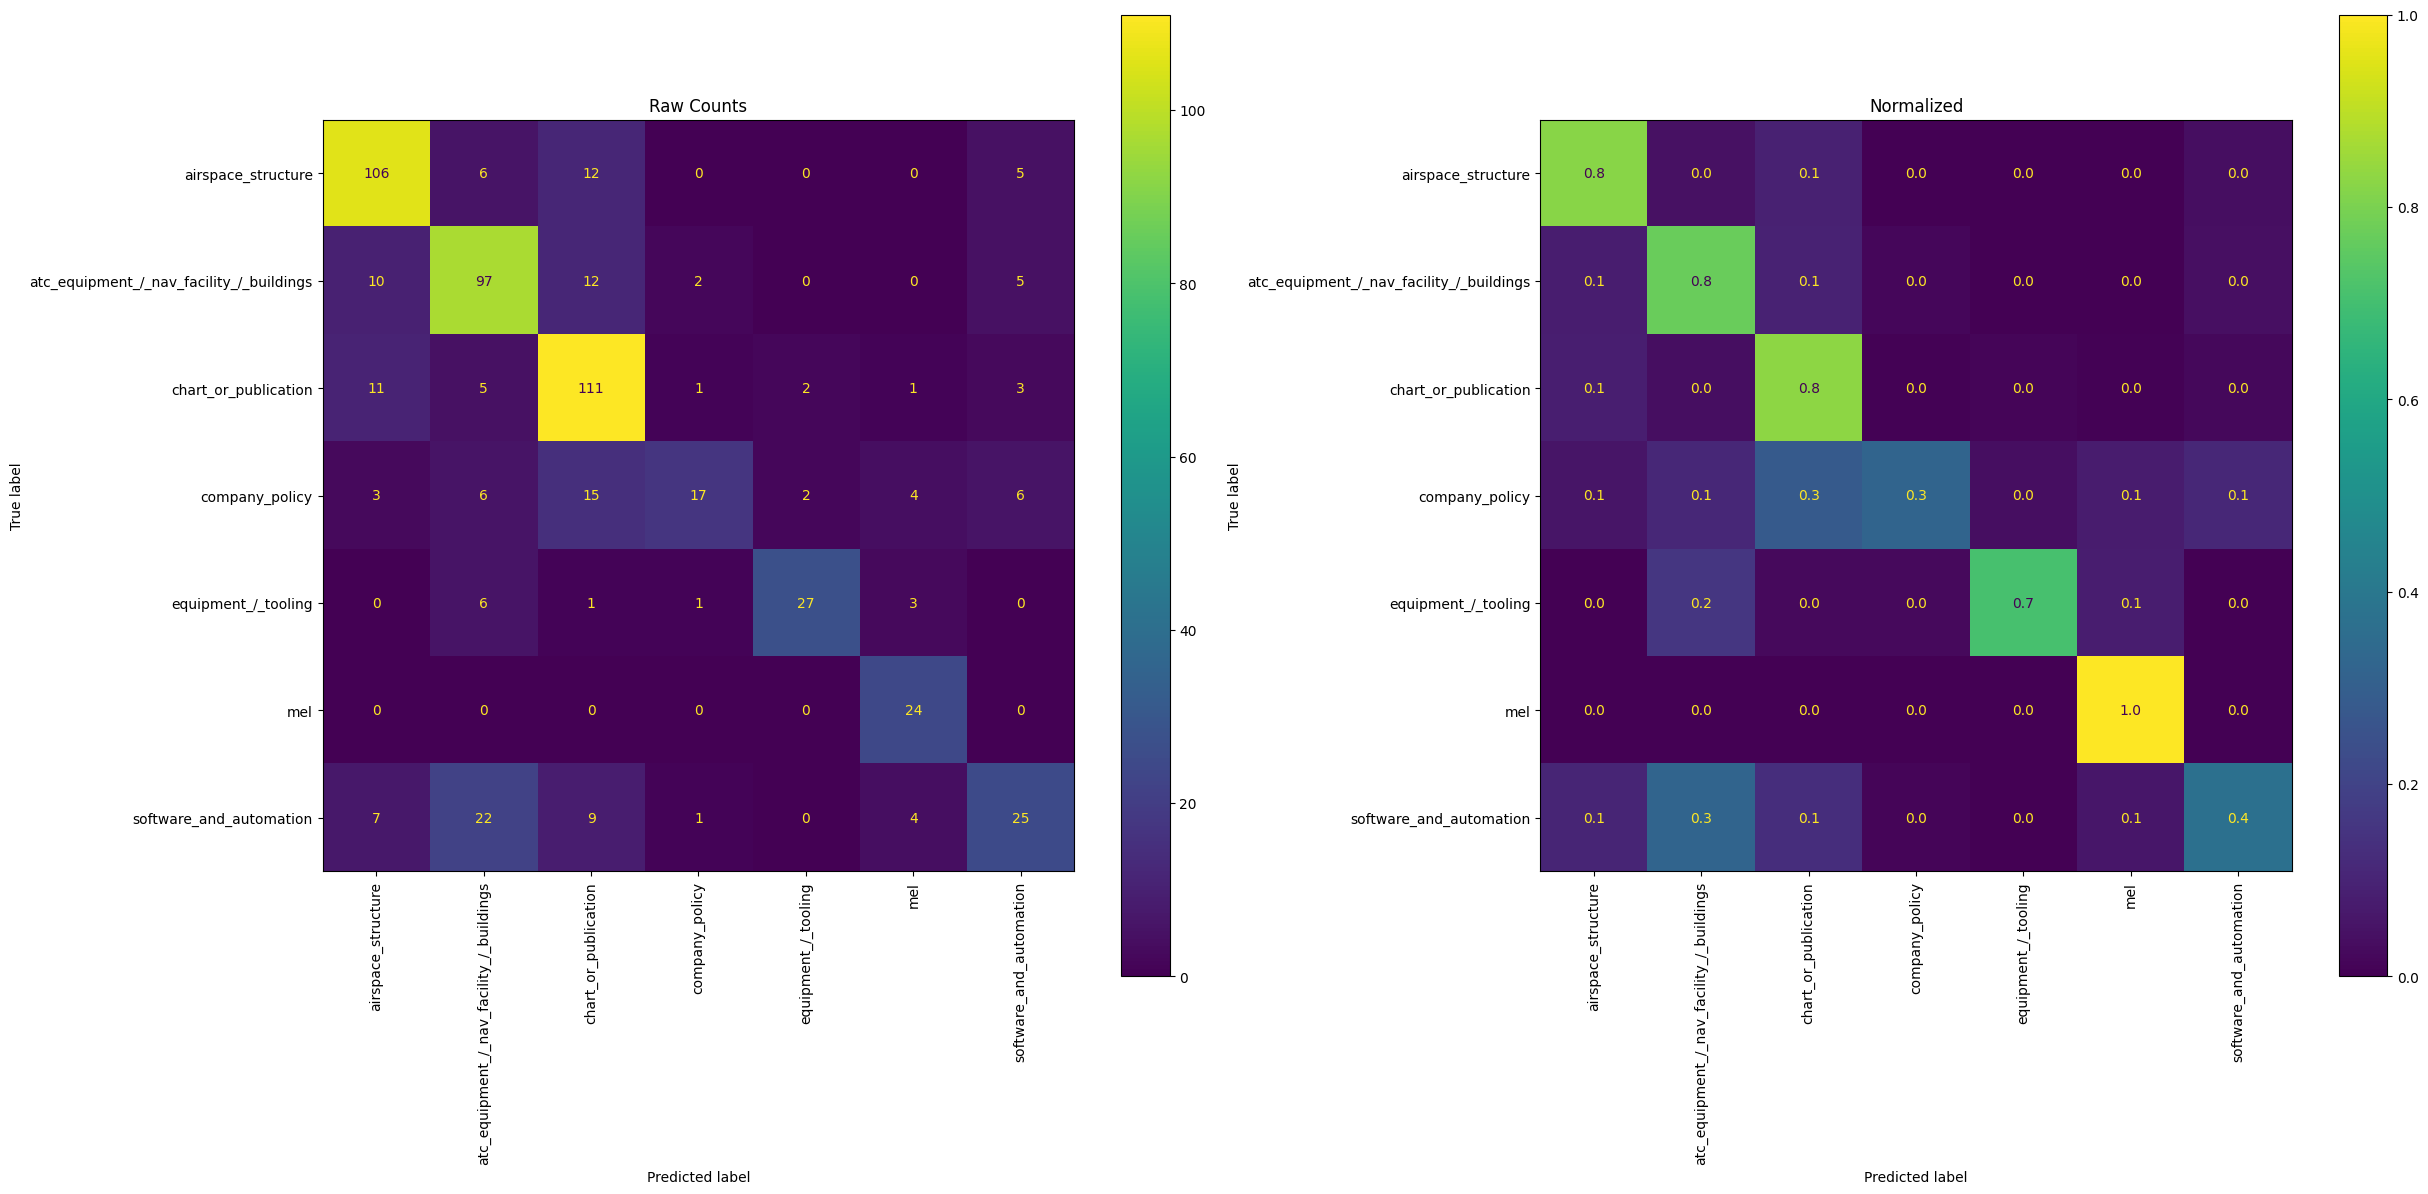

In [215]:
ms_predY = ms_ovr.predict(ms_testX)
utils.visualize_eval(ms_testY, ms_predY, "Medium Sample")

Low-Sample Confidence

In [216]:
ls_trainX = low_sample_train_df.drop(columns="assessments_primary_problem")
ls_trainY = low_sample_train_df["assessments_primary_problem"]

ls_testX = low_sample_test_df.drop(columns="assessments_primary_problem")
ls_testY = low_sample_test_df["assessments_primary_problem"]

In [217]:
ls_ovr.fit(ls_trainX, ls_trainY)

,estimator,SVC()
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


/home/maciej/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maciej/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maciej/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                                              precision    recall  f1-score   support

                         equipment_/_tooling       0.88      0.92      0.90        38
incorrect_/_not_installed_/_unavailable_part       0.64      0.84      0.73        19
                               logbook_entry       0.00      0.00      0.00         2
                                     manuals       1.00      0.20      0.33        10
                                         mel       0.81      0.92      0.86        24
                                    staffing       0.80      0.73      0.76        11

                                    accuracy                           0.80       104
                                   macro avg       0.69      0.60      0.60       104
                                weighted avg       0.81      0.80      0.77       104



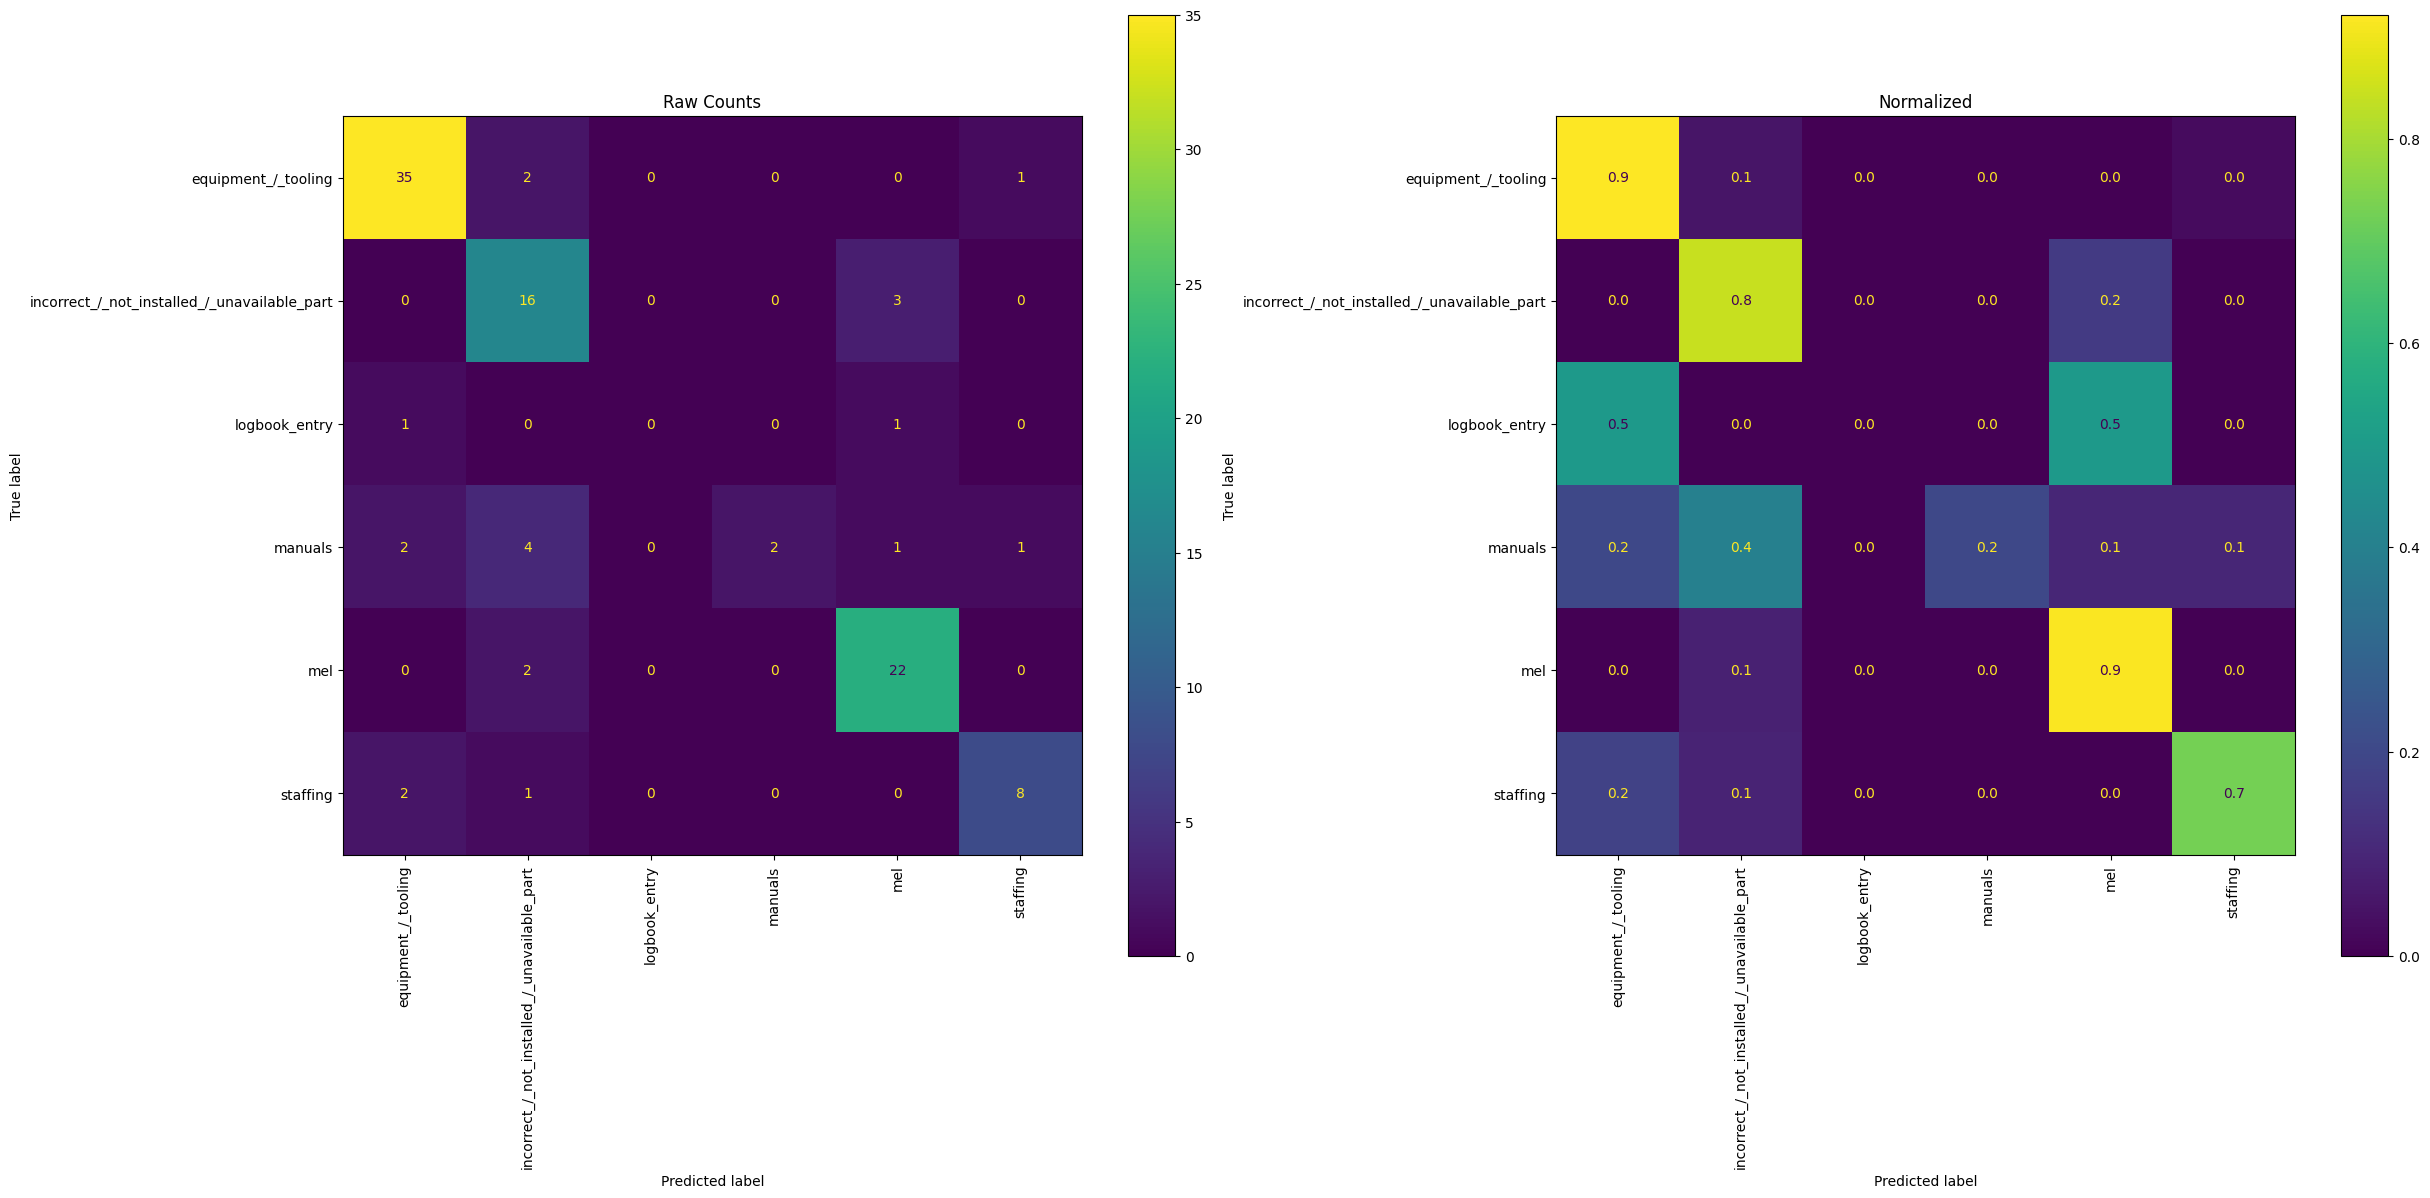

In [218]:
ls_predY = ls_ovr.predict(ls_testX)
utils.visualize_eval(ls_testY, ls_predY, "Low Sample")

Human-Factors/Procedure Classifier

In [219]:
hfp_trainX = hf_proc_train_df.drop(columns="assessments_primary_problem")
hfp_trainY = hf_proc_train_df["assessments_primary_problem"]

hfp_testX = hf_proc_test_df.drop(columns="assessments_primary_problem")
hfp_testY = hf_proc_test_df["assessments_primary_problem"]

In [220]:
hfp_ovr.fit(hfp_trainX, hfp_trainY)

,estimator,SVC()
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


               precision    recall  f1-score   support

     aircraft       0.88      0.97      0.92      3286
human_factors       0.79      0.89      0.84      3359
    procedure       0.67      0.14      0.23       962

     accuracy                           0.83      7607
    macro avg       0.78      0.67      0.66      7607
 weighted avg       0.81      0.83      0.80      7607



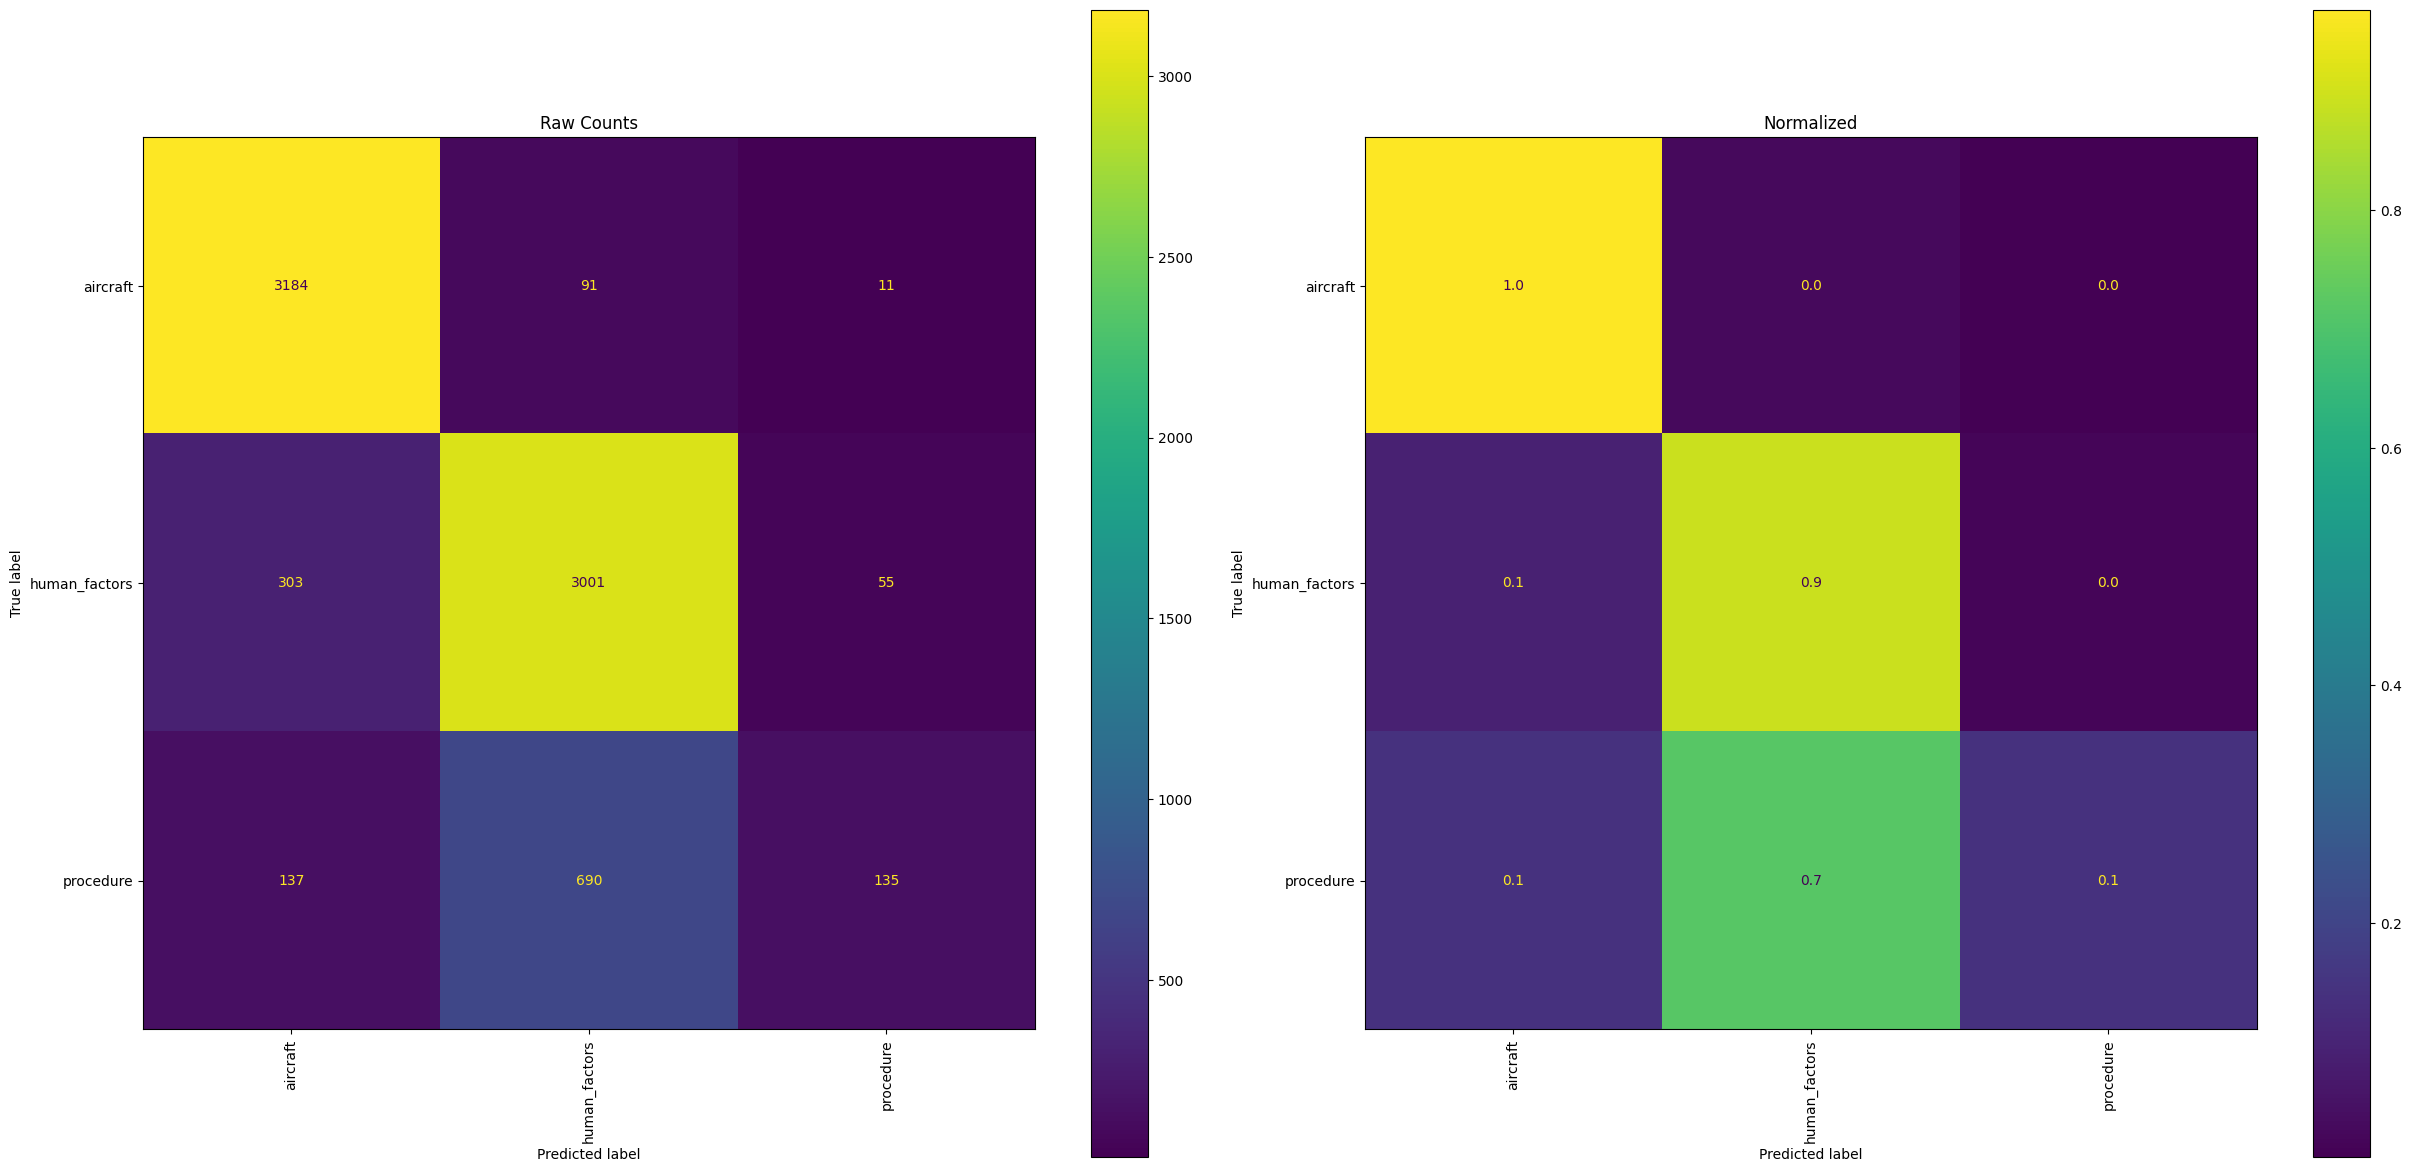

In [221]:
hfp_predY = hfp_ovr.predict(hfp_testX)
utils.visualize_eval(hfp_testY, hfp_predY, "Human Factors and Procedures")

### Stacking Classifiers

In [234]:
# Trying undersampling techniques
excluding_least_df = onehot_events_df[(onehot_events_df["assessments_primary_problem"] != "logbook_entry") &
                                      (onehot_events_df["assessments_primary_problem"] != "staffing") &
                                      (onehot_events_df["assessments_primary_problem"] != "manuals")]

trainX_RandomUnder = excluding_least_df.drop(columns="assessments_primary_problem")
trainY_RandomUnder = excluding_least_df["assessments_primary_problem"]

rus = RandomUnderSampler()
trainX_RandomUnder, trainY_RandomUnder = rus.fit_resample(trainX_RandomUnder, trainY_RandomUnder)
trainY_RandomUnder.value_counts()

assessments_primary_problem
aircraft                                        48
airport                                         48
airspace_structure                              48
ambiguous                                       48
atc_equipment_/_nav_facility_/_buildings        48
chart_or_publication                            48
company_policy                                  48
environment___non_weather_related               48
equipment_/_tooling                             48
human_factors                                   48
incorrect_/_not_installed_/_unavailable_part    48
mel                                             48
procedure                                       48
software_and_automation                         48
weather                                         48
Name: count, dtype: int64

In [232]:
# Trying different oversampling techniques
smt = SMOTE(k_neighbors=1)
ros = RandomOverSampler()

trainX_SMOTE, trainY_SMOTE = smt.fit_resample(trainX, trainY)
trainX_RandomOver, trainY_RandomOver = ros.fit_resample(trainX, trainY)

print(trainY_SMOTE.value_counts())
print(trainY_RandomOver.value_counts())


assessments_primary_problem
ambiguous                                       3516
human_factors                                   3516
weather                                         3516
environment___non_weather_related               3516
aircraft                                        3516
software_and_automation                         3516
procedure                                       3516
airport                                         3516
airspace_structure                              3516
staffing                                        3516
chart_or_publication                            3516
atc_equipment_/_nav_facility_/_buildings        3516
equipment_/_tooling                             3516
mel                                             3516
company_policy                                  3516
incorrect_/_not_installed_/_unavailable_part    3516
manuals                                         3516
logbook_entry                                   3516
Name: count, dtype

In [233]:
# Combining over and undersampling techinques
smtenn = SMOTEENN(smote=smt)            # Set SMOTE object to smt to use the k_neighbors=1 configuration
smtomk = SMOTETomek(smote=smt)

trainX_UnderOver, trainY_UnderOver = rus.fit_resample(trainX_RandomOver, trainY_RandomOver)

print(trainY_UnderOver.value_counts())

#trainX_SMOTEENN, trainY_SMOTEENN = smtenn.fit_resample(trainX, trainY)
#trainX_SMOTETomek, trainY_SMOTETomek = smtomk.fit_resample(trainX, trainY)

assessments_primary_problem
aircraft                                        3516
airport                                         3516
airspace_structure                              3516
ambiguous                                       3516
atc_equipment_/_nav_facility_/_buildings        3516
chart_or_publication                            3516
company_policy                                  3516
environment___non_weather_related               3516
equipment_/_tooling                             3516
human_factors                                   3516
incorrect_/_not_installed_/_unavailable_part    3516
logbook_entry                                   3516
manuals                                         3516
mel                                             3516
procedure                                       3516
software_and_automation                         3516
staffing                                        3516
weather                                         3516
Name: count, dtype

In [ ]:
final_estimator = LogisticRegression(max_iter=1000, class_weight="balanced") # Default final_estimator is already logistic regression, but I needed to increase number of iterations

stacking_classifier = StackingClassifier([("ovr_high", hs_ovr), ("ovr_medium", ms_ovr), ("ovr_low", ls_ovr), ("hfp", hfp_ovr)], 
                                         final_estimator=final_estimator,
                                         passthrough=True, 
                                         cv="prefit")   

#stacking_classifier.fit(trainX_SMOTE, trainY_SMOTE)
#stacking_classifier.fit(trainX_RandomOver, trainY_RandomOver)
#stacking_classifier.fit(trainX_RandomUnder, trainY_RandomUnder)    # Works best but sacrifices lowest 3 categories
#stacking_classifier.fit(trainX_UnderOver, trainY_UnderOver)
#stacking_classifier.fit(trainX_SMOTEENN, trainY_SMOTEENN)
#stacking_classifier.fit(trainX_SMOTETomek, trainY_SMOTETomek)

stacking_classifier.fit(trainX, trainY)                        # Seems to work better without any over/under sampling

,estimators,"[('ovr_high', ...), ('ovr_medium', ...), ...]"
,final_estimator,LogisticRegre...max_iter=1000)
,cv,'prefit'
,stack_method,'auto'
,n_jobs,None
,passthrough,True
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


                                              precision    recall  f1-score   support

                                    aircraft       0.90      0.84      0.87      3286
                                     airport       0.25      0.43      0.32       244
                          airspace_structure       0.10      0.53      0.17       129
                                   ambiguous       0.28      0.33      0.31       795
    atc_equipment_/_nav_facility_/_buildings       0.22      0.41      0.29       126
                        chart_or_publication       0.27      0.49      0.35       134
                              company_policy       0.05      0.15      0.08        53
           environment___non_weather_related       0.18      0.29      0.23       238
                         equipment_/_tooling       0.17      0.42      0.24        38
                               human_factors       0.72      0.40      0.51      3359
incorrect_/_not_installed_/_unavailable_part       0.

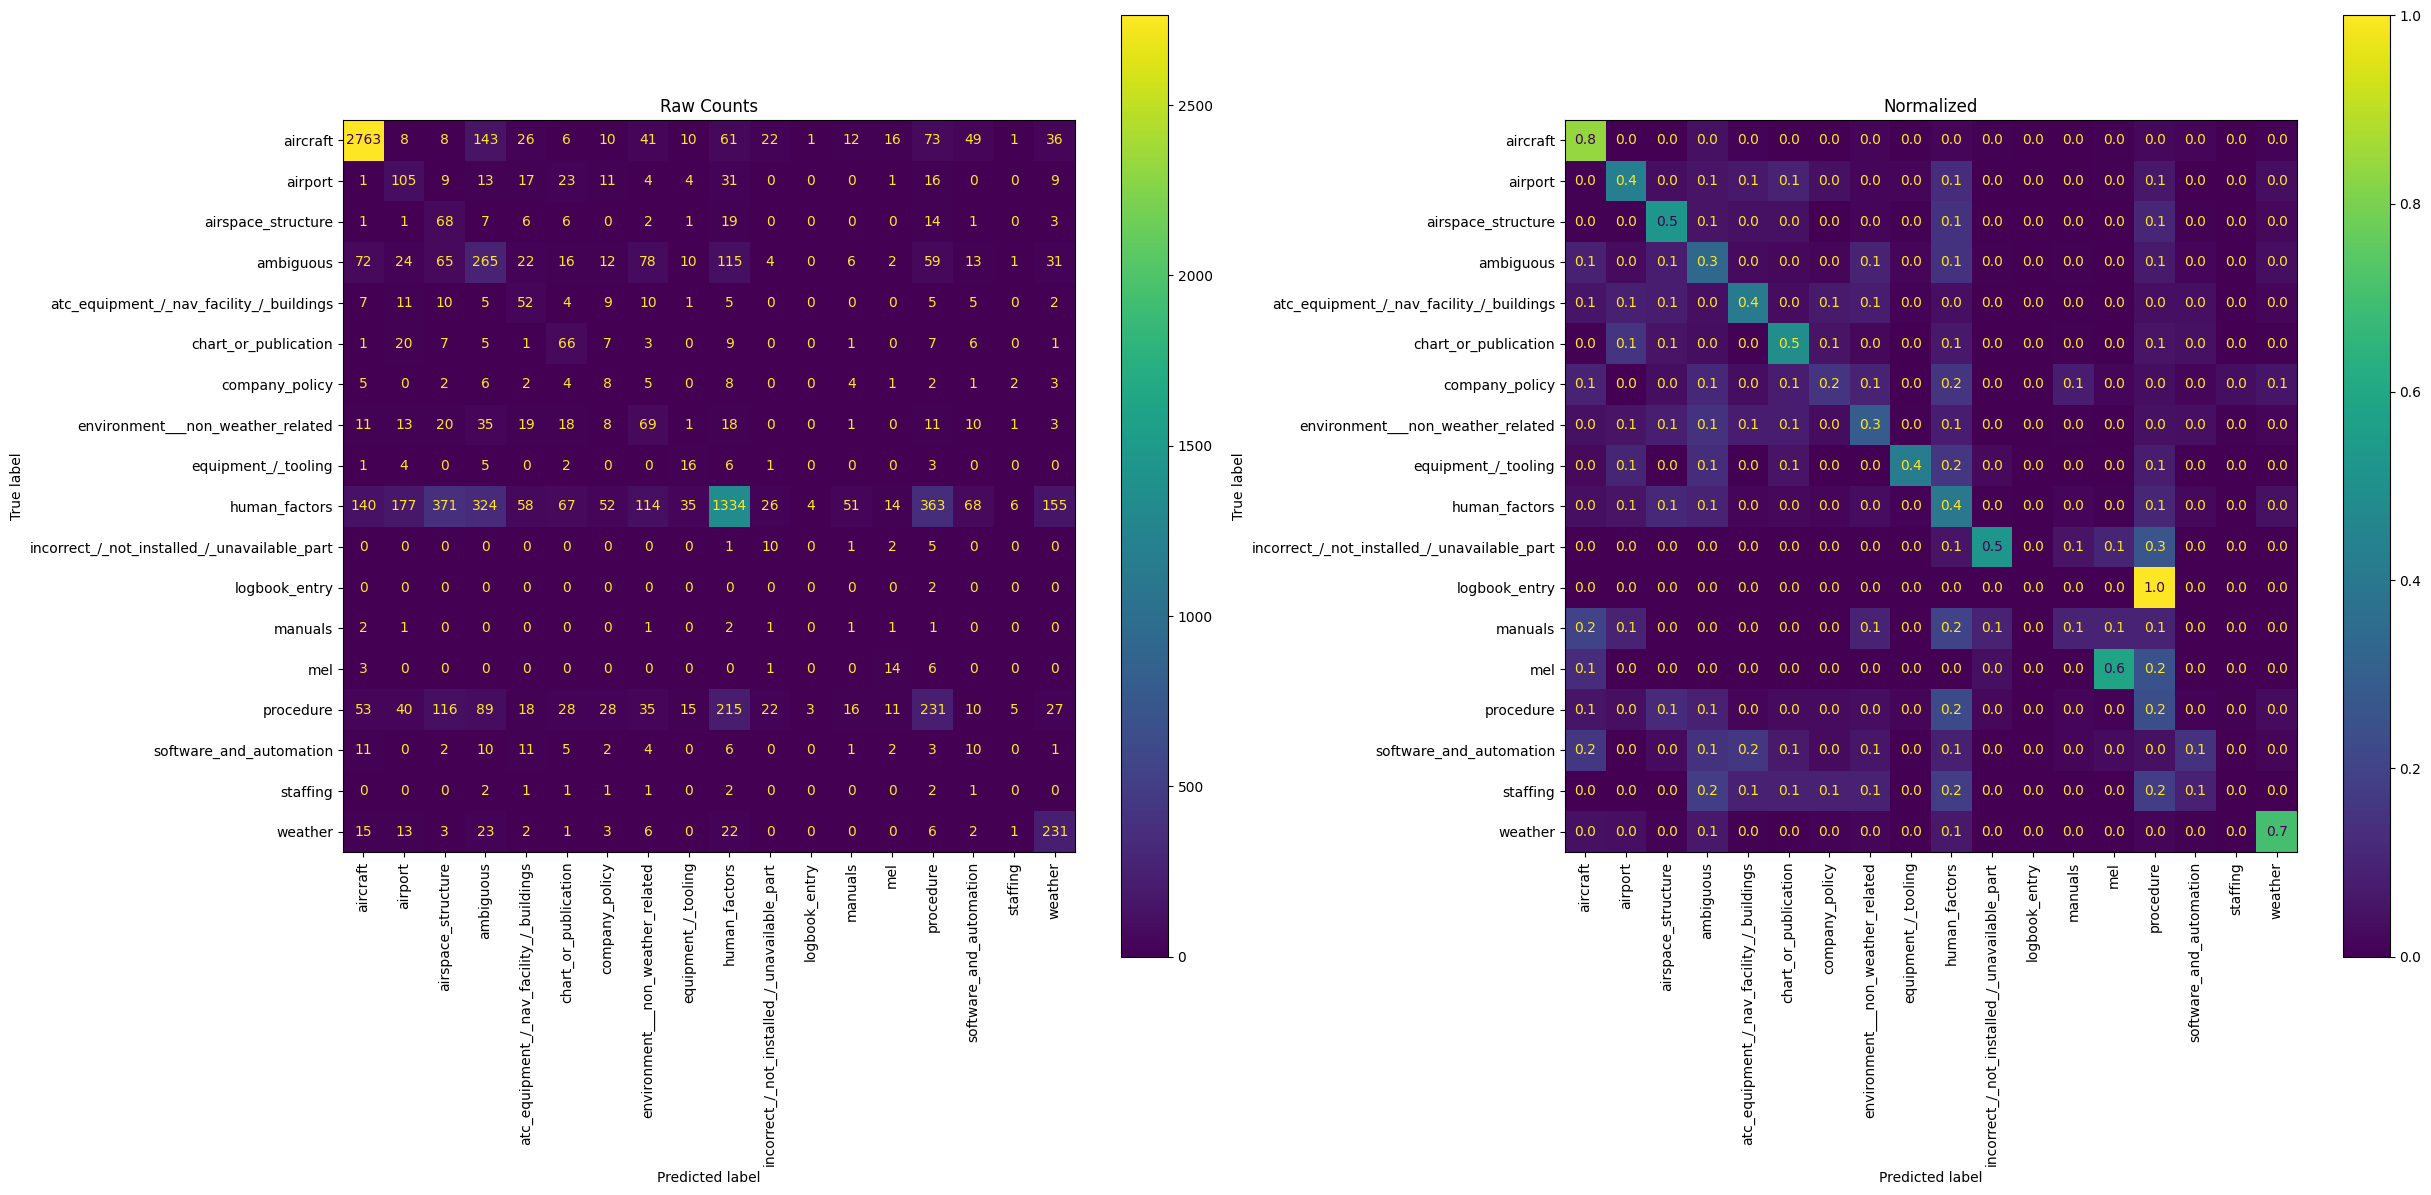

In [226]:
st_predY = stacking_classifier.predict(testX)
utils.visualize_eval(testY, st_predY, "Stacking Classifiers")

In [227]:
onehot_events_df["assessments_primary_problem"].value_counts()

assessments_primary_problem
human_factors                                   8384
aircraft                                        8207
procedure                                       2403
ambiguous                                       1985
weather                                          821
airport                                          609
environment___non_weather_related                595
chart_or_publication                             335
airspace_structure                               321
atc_equipment_/_nav_facility_/_buildings         316
software_and_automation                          168
company_policy                                   132
equipment_/_tooling                               96
mel                                               57
incorrect_/_not_installed_/_unavailable_part      48
staffing                                          27
manuals                                           25
logbook_entry                                      5
Name: count, dtype

Hyperparameter Tuning

In [228]:
# Because we are tuning the LogisticRegression classifier that is a part of a stacking classifier, the parameters
# need to be prefixed with "final_estimator__"
parameters = { "final_estimator__C" : [0.01, 0.1, 1.0],
               "passthrough" : [True, False] }

In [229]:
gs = GridSearchCV(estimator=stacking_classifier, param_grid=parameters, scoring="f1_macro", cv=5)
gs.fit(trainX_SMOTE, trainY_SMOTE)

ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/home/maciej/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/maciej/.local/lib/python3.10/site-packages/sklearn/ensemble/_stacking.py", line 706, in fit
    return super().fit(X, y_encoded, **fit_params)
  File "/home/maciej/.local/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/maciej/.local/lib/python3.10/site-packages/sklearn/ensemble/_stacking.py", line 205, in fit
    check_is_fitted(estimator)
  File "/home/maciej/.local/lib/python3.10/site-packages/sklearn/utils/validation.py", line 1754, in check_is_fitted
    raise NotFittedError(msg % {"name": type(estimator).__name__})
sklearn.exceptions.NotFittedError: This OneVsRestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
